Configuration

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

FOLDER_PATH = os.getenv("KATAKANA_FOLDER_PATH")
files = [FOLDER_PATH]
OUTPUT_PATH = os.getenv("OUTPUT_PATH")

jisx0201_katakana_map = {
    0xB1: 'ア', 0xB2: 'イ', 0xB3: 'ウ', 0xB4: 'エ', 0xB5: 'オ',
    0xB6: 'カ', 0xB7: 'キ', 0xB8: 'ク', 0xB9: 'ケ', 0xBA: 'コ',
    0xBB: 'サ', 0xBC: 'シ', 0xBD: 'ス', 0xBE: 'セ', 0xBF: 'ソ',
    0xC0: 'タ', 0xC1: 'チ', 0xC2: 'ツ', 0xC3: 'テ', 0xC4: 'ト',
    0xC5: 'ナ', 0xC6: 'ニ', 0xC7: 'ヌ', 0xC8: 'ネ', 0xC9: 'ノ',
    0xCA: 'ハ', 0xCB: 'ヒ', 0xCC: 'フ', 0xCD: 'ヘ', 0xCE: 'ホ',
    0xCF: 'マ', 0xD0: 'ミ', 0xD1: 'ム', 0xD2: 'メ', 0xD3: 'モ',
    0xD4: 'ヤ', 0xD5: 'ユ', 0xD6: 'ヨ',
    0xD7: 'ラ', 0xD8: 'リ', 0xD9: 'ル', 0xDA: 'レ', 0xDB: 'ロ',
    0xDC: 'ワ', 0xA6: 'ヲ', 0xDD: 'ン'
}

def jis_to_unicode(jis_code):
    # JIS X 0201
    return jisx0201_katakana_map.get(jis_code, '')

def unicode_to_jis(char):
    # JIS X 0201
    for jis_code, unicode_char in jisx0201_katakana_map.items():
        if unicode_char == char:
            return jis_code

katakana =[
    'ア', 'イ', 'ウ', 'エ', 'オ',
    'カ', 'キ', 'ク', 'ケ', 'コ',
    'サ', 'シ', 'ス', 'セ', 'ソ',
    'タ', 'チ', 'ツ', 'テ', 'ト',
    'ナ', 'ニ', 'ヌ', 'ネ', 'ノ',
    'ハ', 'ヒ', 'フ', 'ヘ', 'ホ',
    'マ', 'ミ', 'ム', 'メ', 'モ',
    'ヤ', 'ユ', 'ヨ',
    'ラ', 'リ', 'ル', 'レ', 'ロ',
    'ワ', 'ヲ', 'ン'
]


selected_characters = katakana

selected_jis = []

for char in selected_characters:
    jis_code = unicode_to_jis(char)
    selected_jis.append(jis_code)

print(f"Selected JIS codes: {selected_jis}")

Preprocess functions

In [ ]:
import tensorflow as tf
from dataclasses import dataclass
import numpy as np
import cv2


@dataclass
class Record:
    """One record from a file ETL9G."""
    jis_code: int
    img: np.ndarray


def swap_white_and_black(img: np.ndarray) -> np.ndarray:
    """
    Swaps white and black pixels in the image.
    """
    return 15 - img


def clean_image_background(img: np.ndarray) -> np.ndarray:
    """
    Removes unwanted objects that touch the edges of the image.
    This helps eliminate neighboring fragments that result from scanning multiple samples from one sheet.
    Uses bfs to find connected components touching the edges and removes them.
    """
    # TODO: remove small objects inside the image
    # TOOD: check y and x order
    h, w = img.shape
    visited = np.zeros((h, w), dtype=bool)

    def bfs(start_x: int, start_y: int):
        queue = [(start_x, start_y)]
        while queue:
            x, y = queue.pop(0)
            if visited[x, y]:
                continue
            visited[x, y] = True
            if img[x, y] > 14:   # thershold
                img[x, y] = 0
                for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < h and 0 <= ny < w and not visited[nx, ny]:
                        queue.append((nx, ny))

    for i in range(h):
        if not visited[i, 0]:
            bfs(i, 0)
        if not visited[i, w - 1]:
            bfs(i, w - 1)
    for i in range(w):
        if not visited[0, i]:
            bfs(0, i)
        if not visited[h - 1, i]:
            bfs(h - 1, i)

    return img


def cut_center_and_scale(img: np.ndarray, add_margin: bool = False) -> np.ndarray:
    """
    Cuts the center of the image and scales it to a fixed size.
    """
    mask = img > 1
    coords = np.argwhere(mask)

    if coords.size == 0:
        return img
    
    # TODO: check if +1 is needed
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1  # slices are exclusive at the top and bottom
    cropped_img = img[y0:y1, x0:x1]
    ch, cw = cropped_img.shape
    if add_margin:
        cropped_img = np.pad(cropped_img, pad_width=2, mode='constant', constant_values=0)

    scale = min(127 / ch, 128 / cw)
    new_h = int(ch * scale)
    new_w = int(cw * scale)

    scaled_img = tf.image.resize(
        cropped_img[..., np.newaxis],
        (new_h, new_w), method='bilinear'
    ).numpy()
    
    canvas = np.zeros((127, 128, 1), dtype=scaled_img.dtype)

    y_offset = (127 - new_h) // 2
    x_offset = (128 - new_w) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w, :] = scaled_img

    return canvas.astype(np.uint8).squeeze()


def convert_to_binary_image(img: np.ndarray, threshold = 3) -> np.ndarray:
    """
    Converts grayscale image to binary (black and white) image using thresholding.
    """
    binary_img = np.where(img > threshold, 15, 0).astype(np.uint8)
    return binary_img


def smooth_edges(img: np.ndarray, kernel_size: int = 7) -> np.ndarray:
    """
    Smooths the edges of the image using Gaussian blur.
    """
    img = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    return img


def thin_lines(img: np.ndarray, kernel_size: int = 2) -> np.ndarray:
    """
    Thins the lines in the image using morphological operations.
    """
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    img = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
    return img

2025-12-09 18:46:40.424831: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-09 18:46:40.470693: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-09 18:46:43.726181: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Dynamic threshold: 4


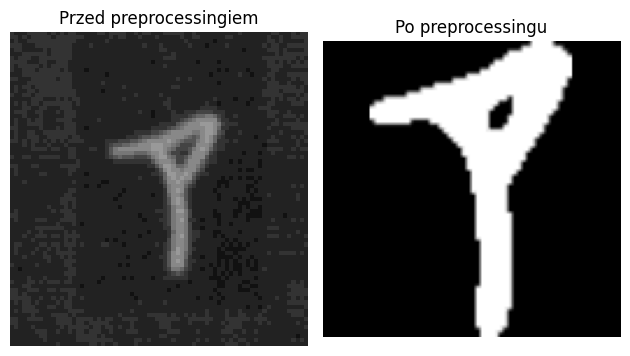

Dynamic threshold: 4


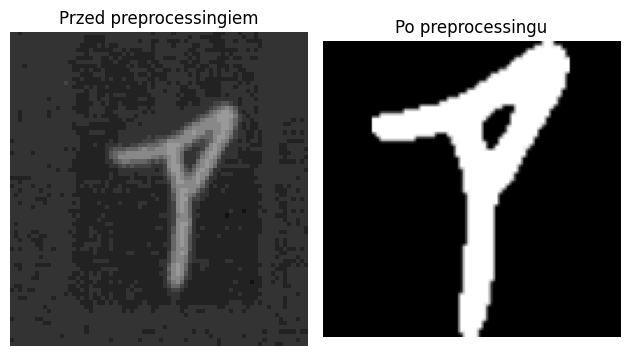

Dynamic threshold: 4


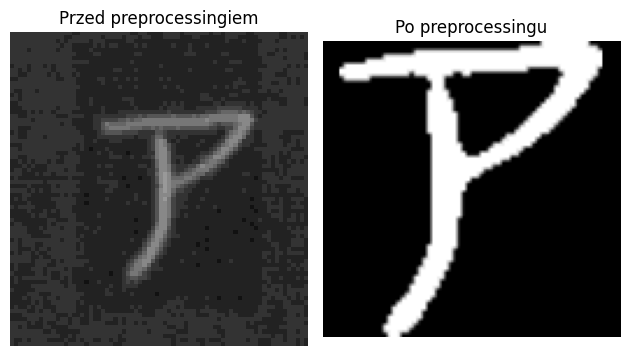

Dynamic threshold: 4


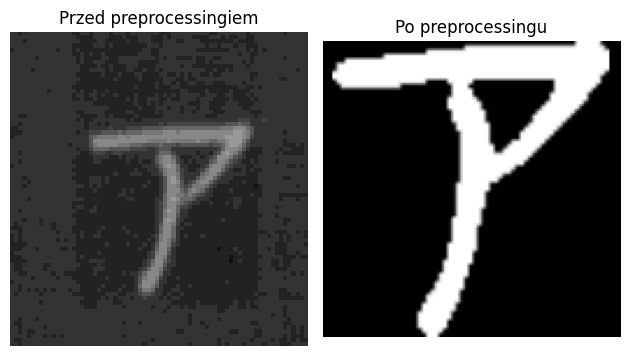

Dynamic threshold: 3


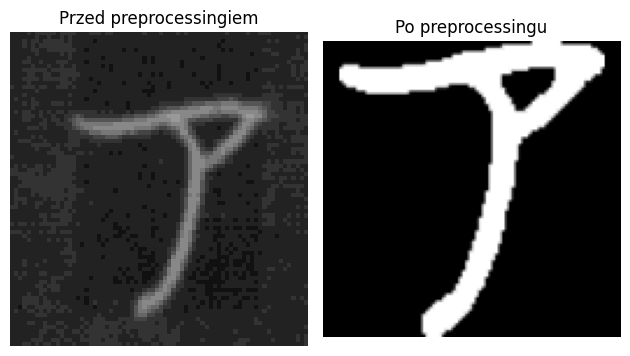

Dynamic threshold: 4


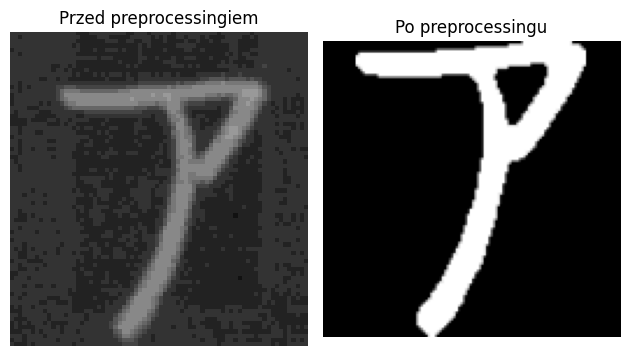

[Record(jis_code=177, img=array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(127, 128), dtype=uint8)),
 Record(jis_code=177, img=array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(127, 128), dtype=uint8)),
 Record(jis_code=177, img=array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(127, 128), dtype=uint8)),
 Record(jis_code=177, img=array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..

In [ ]:
from typing import BinaryIO, Optional

from matplotlib import pyplot as plt


def get_dynamic_threshold(img: np.ndarray) -> int:
    """
    Oblicza dynamiczny próg binaryzacji dla obrazów ETL (0–15)
    na podstawie normalizacji do zakresu 0–255 i OTSU.
    Zwraca próg w skali 0–15.
    """
    # Konwersja 0–15 → 0–255
    img_scaled = (img.astype(np.float32) / 15.0 * 255).astype(np.uint8)

    # Otsu zwraca liczbę — jeśli obraz jest poprawny
    th, _ = cv2.threshold(
        img_scaled, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Konwersja z powrotem do progu ETL
    th_etl = int(th / 17)

    # Ograniczenie żeby nie było 0 ani 15 (bo obraz może być jednolity)
    th_etl = max(1, min(14, th_etl))

    print("Dynamic threshold:", th_etl)
    return th_etl



def simple_preprocess(img: np.ndarray) -> np.ndarray:
    """
    Simple preprocessing steps.
    """
    # img = convert_to_binary_image(img)
    # img = clean_image_background(img)
    img = cut_center_and_scale(img)
    threshold = get_dynamic_threshold(img)
    img = smooth_edges(img)
    img = convert_to_binary_image(img, threshold = threshold)
    img = cut_center_and_scale(img)
    return img


def clean_image_background(img: np.ndarray) -> np.ndarray:
    """
    Removes unwanted objects that touch the edges of the image.
    This helps eliminate neighboring fragments that result from scanning multiple samples from one sheet.
    Uses bfs to find connected components touching the edges and removes them.
    """
    # TODO: remove small objects inside the image
    # TOOD: check y and x order
    h, w = img.shape
    visited = np.zeros((h, w), dtype=bool)

    def bfs(start_x: int, start_y: int):
        queue = [(start_x, start_y)]
        while queue:
            x, y = queue.pop(0)
            if visited[x, y]:
                continue
            visited[x, y] = True
            if img[x, y] > 3:   # thershold
                img[x, y] = 0
                for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < h and 0 <= ny < w and not visited[nx, ny]:
                        queue.append((nx, ny))

    for i in range(h):
        if not visited[i, 0]:
            bfs(i, 0)
        if not visited[i, w - 1]:
            bfs(i, w - 1)
    for i in range(w):
        if not visited[0, i]:
            bfs(0, i)
        if not visited[h - 1, i]:
            bfs(h - 1, i)

    return img


def read_etl5_records_from_file(f: BinaryIO) -> Optional[Record]:
    """
    Reads one record from a file ETL5.
    Returns: (jis_code, img)
    """
    jis_start_bit = 12*6
    jis_char_length = 8
    image_start_bit = 288*6
    image_char_length = 3648*6

    s = f.read(2952)
    if not s or len(s) < 2952:
        return None
    
    bits = ''.join(f"{byte:08b}" for byte in s)

    jis_bits = bits[jis_start_bit: jis_start_bit + jis_char_length]
    jis_code = int(jis_bits, 2)

    image_bits = bits[image_start_bit: image_start_bit + image_char_length]
    pixels = [int(image_bits[i:i+4], 2) for i in range(0, len(image_bits), 4)] 

    img = np.array(pixels, dtype=np.uint8).reshape((76, 72))

    return Record(jis_code, img)




def read_etl9g_all_records() -> list[Record]:
    """
    Reads multiple files ETL9G binary
    """
    skipped = []
    records = []
    i = 0
    skip = 25
    for file in files:
        with open(file, "rb") as f:
            while i < skip + 5:
                i = i + 1
                record = read_etl5_records_from_file(f)
                if record == None:
                    break
                if i < skip:
                    continue
                if record.jis_code in selected_jis:
                    img = record.img

                    plt.subplot(1, 2, 1)
                    plt.imshow(img, cmap='gray', vmin=0, vmax=15)
                    plt.title("Przed preprocessingiem")
                    plt.axis("off")
                    
                    simple_record = Record(record.jis_code, simple_preprocess(img))
                    records.append(simple_record)

                    # Po preprocessing
                    plt.subplot(1, 2, 2)
                    plt.imshow(simple_record.img, cmap='gray')
                    plt.title("Po preprocessingu")
                    plt.axis("off")

                    plt.tight_layout()
                    plt.show()

                else :
                    print(f"Skipping JIS code: {record.jis_code}")
                    skipped.append(record.jis_code)
    return records


read_etl9g_all_records()


177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 3
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 3
177
Dynamic threshold: 3
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 3
177
Dynamic threshold: 3
177
Dynamic threshold: 3
177
Dynamic threshold: 4
177
Dynamic threshold: 3
177
Dynamic threshold: 3
177
Dynamic threshold: 3
177
Dynamic threshold: 3
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 3
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 3
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 2
177
Dynamic threshold: 2
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 4
177
Dynamic threshold: 4


INFO:tensorflow:Assets written to: /media/wikusia/HDD/Studia/Semestr 6/Projekt dyplomowy/repo/models/models/cnn_etl9g_46s_50e_nomargin_smooth_simple/assets


Saved artifact at '/media/wikusia/HDD/Studia/Semestr 6/Projekt dyplomowy/repo/models/models/cnn_etl9g_46s_50e_nomargin_smooth_simple'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 127, 128, 1), dtype=tf.float32, name='keras_tensor_196')
Output Type:
  TensorSpec(shape=(None, 46), dtype=tf.float32, name=None)
Captures:
  134619498082928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134619497496992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134619497620656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134619497616080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134619497626816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134619499157936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134619499158640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134619499151600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134619984081696: TensorSpec(shape=(), dtype=tf.resou

W0000 00:00:1765306217.365781   15927 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1765306217.365837   15927 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-12-09 19:50:17.366232: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /media/wikusia/HDD/Studia/Semestr 6/Projekt dyplomowy/repo/models/models/cnn_etl9g_46s_50e_nomargin_smooth_simple
2025-12-09 19:50:17.367492: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-12-09 19:50:17.367501: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /media/wikusia/HDD/Studia/Semestr 6/Projekt dyplomowy/repo/models/models/cnn_etl9g_46s_50e_nomargin_smooth_simple
2025-12-09 19:50:17.373691: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-12-09 19:50:17.442450: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /media/wikusia/HDD/St

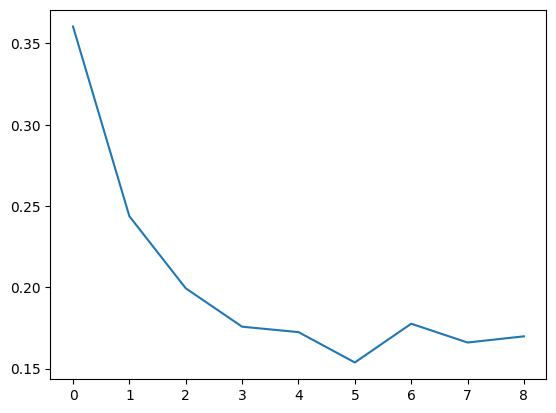

In [ ]:

from typing import BinaryIO, List, Optional
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from dataclasses import dataclass
import struct
import numpy as np
import cv2
import matplotlib.pyplot as plt

@dataclass
class Record:
    """One record from a file ETL9G."""
    jis_code: int
    img: np.ndarray

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


def read_etl5_records_from_file(f: BinaryIO) -> Optional[Record]:
    """
    Reads one record from a file ETL5.
    Returns: (jis_code, img)
    """
    jis_start_bit = 12*6
    jis_char_length = 8
    image_start_bit = 288*6
    image_char_length = 3648*6

    s = f.read(2952)
    if not s or len(s) < 2952:
        return None
    
    bits = ''.join(f"{byte:08b}" for byte in s)

    jis_bits = bits[jis_start_bit: jis_start_bit + jis_char_length]
    jis_code = int(jis_bits, 2)
    print(jis_code)

    image_bits = bits[image_start_bit: image_start_bit + image_char_length]
    pixels = [int(image_bits[i:i+4], 2) for i in range(0, len(image_bits), 4)] 

    img = np.array(pixels, dtype=np.uint8).reshape((76, 72))

    return Record(jis_code, img)


def read_etl9g_all_records() -> List[Record]:
    """
    Reads multiple files ETL9G binary
    """
    skipped = []
    records = []
    for file in files:
        with open(file, "rb") as f:
            while True:
                record = read_etl5_records_from_file(f)
                if record == None:
                    break
                if record.jis_code in selected_jis:
                    img = record.img
                    simple_record = Record(record.jis_code, simple_preprocess(img))
                    records.append(simple_record)

                else :
                    print(f"Skipping JIS code: {record.jis_code}")
                    skipped.append(record.jis_code)
    return records


# def simple_preprocess(img: np.ndarray) -> np.ndarray:
#     """
#     Simple preprocessing steps.
#     """
#     img = clean_image_background(img)
#     # img = cut_center_and_scale(img)
#     # # img = smooth_edges(img)
#     # img = convert_to_binary_image(img)
#     # img = swap_white_and_black(img)
#     return img

def create_cnn(with_augmentation=True):
    model = tf.keras.Sequential()
    model.add(layers.Input(shape=(127, 128, 1)))

    if with_augmentation:
        model.add(tf.keras.Sequential([
            layers.RandomRotation(0.1),
            layers.RandomZoom(height_factor=(-0.1, 0.0), width_factor=(-0.1, 0.0)),
            # layers.RandomTranslation(0.1, 0.1),   # not needed because images are centered
            # layers.RandomFlip("horizontal")       # shouldn't be used for writing
        ]))

    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(len(selected_jis), activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


def split_data(records: List[Record]) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Splits the data into training and testing sets.
    """
    images = np.array([record.img for record in records])
    labels = np.array([selected_jis.index(record.jis_code) for record in records])

    images = images[..., np.newaxis]  # add channel dimension

    images_train, images_test, labels_train, labels_test = train_test_split(
        images, labels, test_size=0.2, random_state=42, stratify=labels
    )

    return images_train, images_test, labels_train, labels_test


def save_model(model: tf.keras.Model, path: str):
    """
    Saves the model to the specified path.
    """
    model.export(path)
    converter = tf.lite.TFLiteConverter.from_saved_model(path)
    tflite_model = converter.convert()
    with open(f"{path}.tflite", "wb") as f:
        f.write(tflite_model)


if __name__ == "__main__":
    records = read_etl9g_all_records()
    images_train, images_test, labels_train, labels_test = split_data(records)

    model = create_cnn(with_augmentation=True)
    # TODO: check if summary needed
    # model.summary()
    history = model.fit(
        images_train, labels_train,
        validation_data=(images_test, labels_test),
        epochs=50,
        shuffle=True,
        callbacks=[early_stop]
    )
    plt.plot(history.history['val_loss'])

    model_no_augmentation = create_cnn(with_augmentation=False)
    model_no_augmentation.set_weights(model.get_weights())
    save_model(model_no_augmentation, f"{OUTPUT_PATH}/cnn_etl9g_{len(selected_jis)}s_50e_nomargin_smooth_simple")

